In [ ]:
### Uncomment this line to install the necessary depnendencies
!pip install rank-bm25 numpy pandas sentence-transformers tabulate matplotlib seaborn torch

In [1]:
import csv
from rank_bm25 import BM25Okapi
import string
import time
import numpy as np
import pandas as pd
from sentence_transformers import CrossEncoder
from tabulate import tabulate
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import torch
import os

# Configure GPU usage for Apple Silicon (M1/M2/M3)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU via MPS")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU")

# Set environment variable to enable Metal performance optimization
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

csv.field_size_limit(1000000)

Using Apple Silicon GPU via MPS


131072

In [2]:
def load_docs_from_csv(csv_path="all_the_news_cleaned.csv"):
    """
    Load preprocessed documents from a CSV file.
    
    Args:
        csv_path (str): Path to the CSV file containing documents.
        
    Returns:
        list: List of dictionaries, where each dictionary represents a document.
    """
    docs = []
    with open(csv_path, "r", newline='', encoding="utf-8") as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            docs.append(row)
    return docs

def simple_tokenizer(text): 
    """
    Tokenize text by converting to lowercase, removing punctuation, and splitting on spaces.
    
    Args:
        text (str): Text to tokenize.
        
    Returns:
        list: List of tokens.
    """
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text.split()

def bm25_algorithm(docs, query, top_k=10):
    """
    Perform BM25 retrieval on documents.
    
    Args:
        docs (list): List of document dictionaries.
        query (str): Query string.
        top_k (int): Number of documents to return.
        
    Returns:
        tuple: (list of ranked documents, query latency in seconds)
    """
    start_time = time.time()  # Record start time

    query_tokenized = simple_tokenizer(query)
    tokenized = []
    for doc in docs:
        # Combine multiple fields for better matching
        combined = f"{doc['contents']} {doc['author']} {doc['publication']} {doc['date']}"
        tokenized.append(simple_tokenizer(combined))
    
    bm25 = BM25Okapi(tokenized)
    bm25_scores = bm25.get_scores(query_tokenized)
    ranked_indices = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:top_k]
    
    # Create ranked documents with scores
    ranked_docs = []
    for i in ranked_indices:
        doc = docs[i].copy()  # Create a copy to avoid modifying the original
        doc["score"] = float(bm25_scores[i])  # Add the BM25 score
        ranked_docs.append(doc)

    end_time = time.time()
    latency = end_time - start_time
    return ranked_docs, latency

def sbert_rerank(bm25_docs, query, model_name='cross-encoder/ms-marco-MiniLM-L-6-v2', top_k=5):
    """
    Rerank BM25 results using a SBERT cross-encoder model with GPU acceleration.
    
    Args:
        bm25_docs (list): Documents retrieved by BM25.
        query (str): Query string.
        model_name (str): Name of the cross-encoder model.
        top_k (int): Number of documents to return.
        
    Returns:
        tuple: (list of reranked documents, reranking latency in seconds)
    """
    start_time = time.time()  # Record start time

    # Initialize the cross-encoder model with device configuration
    model = CrossEncoder(model_name, device=device.type)

    # Prepare query-document pairs for scoring
    pairs = [(query, doc['contents']) for doc in bm25_docs]

    # Get scores from SBERT - batch processing for GPU efficiency
    batch_size = 16  # Adjust based on your GPU memory
    sbert_scores = []
    
    # Process in batches for better GPU utilization
    for i in range(0, len(pairs), batch_size):
        batch_pairs = pairs[i:i+batch_size]
        batch_scores = model.predict(batch_pairs)
        sbert_scores.extend(batch_scores)

    # Create reranked documents with scores
    reranked_docs = []
    for doc, score in zip(bm25_docs, sbert_scores):
        doc_copy = doc.copy()  # Create a copy to avoid modifying the original
        doc_copy["bm25_score"] = doc_copy.get("score", 0.0)  # Store the original BM25 score
        doc_copy["score"] = float(score)  # Replace with SBERT score
        reranked_docs.append(doc_copy)

    # Sort by SBERT score (descending)
    reranked_docs.sort(key=lambda x: x["score"], reverse=True)
    
    end_time = time.time()
    latency = end_time - start_time
    
    return reranked_docs[:top_k], latency

In [4]:
def create_ground_truth(docs, query, topic):
    """
    Create ground truth relevance scores based on:
    - query-term matches (content + title)
    - topic keyword matches
    - publication heuristics
    - document recency
    Normalised to a 0–3 scale.
    
    Args:
        docs (list): List of document dictionaries.
        query (str): Query string.
        topic (str): Topic of the query.
        
    Returns:
        dict: Document IDs mapped to relevance scores (0-3).
    """
    topic_keywords = {
        "politics": ["election", "politics", "vote", "democratic", "representation", "suppression", "voter"],
        "sports": ["nba", "basketball", "sports", "athlete", "player", "mental health", "professional"],
        "finance": ["market", "stock", "economy", "financial", "economic", "quantitative easing", "policy"],
        "technology": ["tech", "technology", "ai", "artificial intelligence", "facial recognition", "surveillance", "ethical"],
        "climate": ["climate", "weather", "extreme", "global warming", "environment", "change", "storm"],
        "healthcare": ["medical", "treatment", "healthcare", "disparity", "socioeconomic", "patient", "care"],
        "education": ["learning", "classroom", "student", "remote", "virtual", "teacher", "instruction"],
        "international": ["diplomatic", "trade", "sanctions", "global", "relations", "international", "foreign"]
    }

    relevance_judgments = {}
    query_terms = set(query.lower().split())
    topic_terms = set(topic_keywords.get(topic, []))

    for doc in docs:
        relevance_score = 0
        doc_content = doc.get("contents", "").lower()
        doc_title = doc.get("title", "").lower()
        publication = doc.get("publication", "")
        doc_id = doc["id"]

        # Query term match
        relevance_score += sum(term in doc_content for term in query_terms)
        relevance_score += 2 * sum(term in doc_title for term in query_terms)

        # Topic term match
        relevance_score += 0.5 * sum(term in doc_content for term in topic_terms)
        relevance_score += 1.0 * sum(term in doc_title for term in topic_terms)

        # Domain-specific publication bonus
        domain_bonus = {
            "politics": ["Washington Post", "New York Times", "CNN", "Fox News", "Politico"],
            "finance": ["Wall Street Journal", "Financial Times", "Bloomberg", "The Economist"],
            "technology": ["Wired", "TechCrunch", "The Verge", "MIT Technology Review"],
            "sports": ["ESPN", "Sports Illustrated", "Bleacher Report", "The Athletic"],
            "brexit": ["BBC", "Guardian", "The Times", "Telegraph"],
            "climate": ["National Geographic", "Scientific American", "Nature", "Climate Home News"],
            "healthcare": ["WebMD", "JAMA", "The Lancet", "Health Affairs", "Kaiser Health News"],
            "education": ["Chronicle of Higher Education", "Education Week", "Inside Higher Ed"],
            "international": ["Foreign Policy", "Foreign Affairs", "The Diplomat", "Reuters"]
        }
        if publication in domain_bonus.get(topic, []):
            relevance_score += 2

        # Year weighting
        try:
            year = int(doc.get("date", "").split("-")[0])
            if year >= 2018:
                relevance_score += 1
            elif year >= 2016:
                relevance_score += 0.5
        except:
            pass

        if relevance_score > 3:
            relevance_judgments[doc_id] = relevance_score

    # Normalise to 0–3 scale
    if relevance_judgments:
        max_score = max(relevance_judgments.values())
        for doc_id in relevance_judgments:
            norm_score = math.ceil(3 * relevance_judgments[doc_id] / max_score)
            relevance_judgments[doc_id] = min(3, norm_score)

    return relevance_judgments

In [5]:
def precision_at_k(ranked_docs, ground_truth, k):
    """
    Calculate Precision@K.
    
    Args:
        ranked_docs (list): List of ranked documents.
        ground_truth (dict): Ground truth relevance scores.
        k (int): Cutoff position.
        
    Returns:
        float: Precision@K score.
    """
    if not ranked_docs or k <= 0:
        return 0.0
    
    k = min(k, len(ranked_docs))
    relevant_count = sum(1 for doc in ranked_docs[:k] if doc["id"] in ground_truth)
    return relevant_count / k

def average_precision(ranked_docs, ground_truth):
    """
    Calculate Average Precision for a single query.
    
    Args:
        ranked_docs (list): List of ranked documents.
        ground_truth (dict): Ground truth relevance scores.
        
    Returns:
        float: Average Precision score.
    """
    if not ranked_docs or not ground_truth:
        return 0.0
    
    relevant_count = 0
    sum_precision = 0.0
    
    for i, doc in enumerate(ranked_docs):
        if doc["id"] in ground_truth:
            relevant_count += 1
            sum_precision += relevant_count / (i + 1)
    
    if relevant_count == 0:
        return 0.0
    
    return sum_precision / min(relevant_count, len(ground_truth))

def ndcg_at_k(ranked_docs, ground_truth, k):
    """
    Calculate nDCG@K.
    
    Args:
        ranked_docs (list): List of ranked documents.
        ground_truth (dict): Ground truth relevance scores.
        k (int): Cutoff position.
        
    Returns:
        float: nDCG@K score.
    """
    if not ranked_docs or not ground_truth or k <= 0:
        return 0.0
    
    k = min(k, len(ranked_docs))
    
    # Calculate DCG
    dcg = 0.0
    for i, doc in enumerate(ranked_docs[:k]):
        rel = ground_truth.get(doc["id"], 0)
        # Using 2^rel - 1 for gain and log_2(i+2) for position discount
        dcg += (2 ** rel - 1) / np.log2(i + 2)
    
    # Calculate ideal DCG (IDCG)
    rel_scores = sorted([ground_truth.get(doc["id"], 0) for doc in ranked_docs], reverse=True)
    ideal_rel_scores = sorted(ground_truth.values(), reverse=True)[:k]
    
    # If there are fewer documents than k, pad with zeros
    while len(ideal_rel_scores) < k:
        ideal_rel_scores.append(0)
    
    idcg = 0.0
    for i, rel in enumerate(ideal_rel_scores[:k]):
        idcg += (2 ** rel - 1) / np.log2(i + 2)
    
    # Avoid division by zero
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


In [6]:
def calculate_metrics(ranked_docs, ground_truth, k_values=[5, 10]):
    """
    Calculate all evaluation metrics for a ranked list of documents.
    
    Args:
        ranked_docs (list): List of ranked documents.
        ground_truth (dict): Ground truth relevance scores.
        k_values (list): List of cutoff positions for P@K and nDCG@K.
        
    Returns:
        dict: Dictionary of evaluation metrics.
    """
    metrics = {}
    
    for k in k_values:
        metrics[f"P@{k}"] = precision_at_k(ranked_docs, ground_truth, k)
        metrics[f"nDCG@{k}"] = ndcg_at_k(ranked_docs, ground_truth, k)
    
    metrics["MAP"] = average_precision(ranked_docs, ground_truth)
    
    # Add F1 score calculation
    for k in k_values:
        precision = metrics[f"P@{k}"]
        # For recall, we calculate how many relevant docs were found among top-k
        # out of all relevant docs in ground truth
        effective_ground_truth_size = min(len(ground_truth), 100)  # Limit to a reasonable number
        
        if effective_ground_truth_size > 0:
            recall = sum(1 for doc in ranked_docs[:k] if doc["id"] in ground_truth) / effective_ground_truth_size
        else:
            recall = 0.0
        
        # Calculate F1 score
        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0.0
        
        metrics[f"F1@{k}"] = f1
    
    return metrics

In [7]:
def run_evaluation(docs, queries, topics, bm25_k=20, sbert_k=10):
    """
    Run evaluation for both BM25 and BM25+SBERT configurations.
    
    Args:
        docs (list): List of document dictionaries.
        queries (dict): Dictionary mapping topics to query strings.
        topics (list): List of topics to evaluate.
        bm25_k (int): Number of documents to retrieve with BM25.
        sbert_k (int): Number of documents to return after reranking.
        
    Returns:
        tuple: (bm25_results, sbert_results, bm25_metrics_df, sbert_metrics_df)
    """
    bm25_results = {}
    sbert_results = {}
    bm25_metrics = []
    sbert_metrics = []
    
    print("\nEvaluating BM25 and BM25+SBERT models...")
    
    for topic in topics:
        query = queries[topic]
        print(f"Processing query for topic: {topic}")
        
        # First, run BM25 retrieval
        bm25_docs, bm25_latency = bm25_algorithm(docs, query, top_k=bm25_k)
        
        # Create ground truth relevance judgments
        ground_truth = create_ground_truth(docs, query, topic)
        
        # Calculate BM25 metrics
        bm25_metrics_values = calculate_metrics(bm25_docs, ground_truth)
        
        # Store BM25 results
        bm25_results[topic] = {
            "query": query, 
            "docs": bm25_docs, 
            "latency": bm25_latency,
            "metrics": bm25_metrics_values,
            "ground_truth": ground_truth
        }
        
        # Add to BM25 metrics table
        metrics_row = {
            "Topic": topic,
            "Query": query,
            "P@5": f"{bm25_metrics_values['P@5']:.3f}",
            "P@10": f"{bm25_metrics_values['P@10']:.3f}",
            "F1@5": f"{bm25_metrics_values['F1@5']:.3f}",
            "F1@10": f"{bm25_metrics_values['F1@10']:.3f}",
            "nDCG@5": f"{bm25_metrics_values['nDCG@5']:.3f}",
            "nDCG@10": f"{bm25_metrics_values['nDCG@10']:.3f}",
            "MAP": f"{bm25_metrics_values['MAP']:.3f}",
            "Latency": f"{bm25_latency:.3f}s",
            "GT Size": len(ground_truth)
        }
        bm25_metrics.append(metrics_row)
        
        # Next, run SBERT reranking
        reranking_start = time.time()
        sbert_docs, sbert_rerank_latency = sbert_rerank(bm25_docs, query, top_k=sbert_k)
        sbert_total_latency = bm25_latency + sbert_rerank_latency
        
        # Calculate SBERT metrics
        sbert_metrics_values = calculate_metrics(sbert_docs, ground_truth)
        
        # Store SBERT results
        sbert_results[topic] = {
            "query": query, 
            "docs": sbert_docs, 
            "rerank_latency": sbert_rerank_latency,
            "total_latency": sbert_total_latency,
            "metrics": sbert_metrics_values,
            "ground_truth": ground_truth
        }
        
        # Add to SBERT metrics table
        metrics_row = {
            "Topic": topic,
            "Query": query,
            "P@5": f"{sbert_metrics_values['P@5']:.3f}",
            "P@10": f"{sbert_metrics_values['P@10']:.3f}",
            "F1@5": f"{sbert_metrics_values['F1@5']:.3f}",
            "F1@10": f"{sbert_metrics_values['F1@10']:.3f}",
            "nDCG@5": f"{sbert_metrics_values['nDCG@5']:.3f}",
            "nDCG@10": f"{sbert_metrics_values['nDCG@10']:.3f}",
            "MAP": f"{sbert_metrics_values['MAP']:.3f}",
            "Latency": f"{sbert_total_latency:.3f}s",
            "GT Size": len(ground_truth)
        }
        sbert_metrics.append(metrics_row)
    
    # Convert metrics to DataFrames for easier processing
    bm25_metrics_df = pd.DataFrame(bm25_metrics)
    sbert_metrics_df = pd.DataFrame(sbert_metrics)
    
    return bm25_results, sbert_results, bm25_metrics_df, sbert_metrics_df

In [12]:
def display_metrics_tables(bm25_metrics_df, sbert_metrics_df):
    """
    Display and compare metrics for BM25 and BM25+SBERT in the notebook.
    
    Args:
        bm25_metrics_df (DataFrame): DataFrame with BM25 metrics.
        sbert_metrics_df (DataFrame): DataFrame with BM25+SBERT metrics.
        save_to_file (bool): Deprecated parameter, kept for backward compatibility.
    """
    # Calculate average metrics for BM25
    bm25_avg_metrics = {
        "Topic": "AVERAGE",
        "Query": "-",
        "P@5": f"{bm25_metrics_df['P@5'].apply(float).mean():.3f}",
        "P@10": f"{bm25_metrics_df['P@10'].apply(float).mean():.3f}",
        "F1@5": f"{bm25_metrics_df['F1@5'].apply(float).mean():.3f}",
        "F1@10": f"{bm25_metrics_df['F1@10'].apply(float).mean():.3f}",
        "nDCG@5": f"{bm25_metrics_df['nDCG@5'].apply(float).mean():.3f}",
        "nDCG@10": f"{bm25_metrics_df['nDCG@10'].apply(float).mean():.3f}",
        "MAP": f"{bm25_metrics_df['MAP'].apply(float).mean():.3f}",
        "Latency": f"{bm25_metrics_df['Latency'].str.replace('s', '').apply(float).mean():.3f}s",
        "GT Size": f"{bm25_metrics_df['GT Size'].mean():.1f}"
    }
    
    # Calculate average metrics for SBERT
    sbert_avg_metrics = {
        "Topic": "AVERAGE",
        "Query": "-",
        "P@5": f"{sbert_metrics_df['P@5'].apply(float).mean():.3f}",
        "P@10": f"{sbert_metrics_df['P@10'].apply(float).mean():.3f}",
        "F1@5": f"{sbert_metrics_df['F1@5'].apply(float).mean():.3f}",
        "F1@10": f"{sbert_metrics_df['F1@10'].apply(float).mean():.3f}",
        "nDCG@5": f"{sbert_metrics_df['nDCG@5'].apply(float).mean():.3f}",
        "nDCG@10": f"{sbert_metrics_df['nDCG@10'].apply(float).mean():.3f}",
        "MAP": f"{sbert_metrics_df['MAP'].apply(float).mean():.3f}",
        "Latency": f"{sbert_metrics_df['Latency'].str.replace('s', '').apply(float).mean():.3f}s",
        "GT Size": f"{sbert_metrics_df['GT Size'].mean():.1f}"
    }
    
    # Create all table outputs as strings
    output_strings = []
    
    # BM25 metrics table
    bm25_table = "\n--- BM25 Evaluation Results ---\n"
    bm25_table += tabulate(bm25_metrics_df, headers="keys", tablefmt="grid")
    output_strings.append(bm25_table)
    
    # BM25 average metrics
    bm25_avg_table = "\n--- BM25 Average Metrics ---\n"
    bm25_avg_table += tabulate([bm25_avg_metrics], headers="keys", tablefmt="grid")
    output_strings.append(bm25_avg_table)
    
    # SBERT metrics table
    sbert_table = "\n--- BM25+SBERT Evaluation Results ---\n"
    sbert_table += tabulate(sbert_metrics_df, headers="keys", tablefmt="grid")
    output_strings.append(sbert_table)
    
    # SBERT average metrics
    sbert_avg_table = "\n--- BM25+SBERT Average Metrics ---\n"
    sbert_avg_table += tabulate([sbert_avg_metrics], headers="keys", tablefmt="grid")
    output_strings.append(sbert_avg_table)
    
    # Performance improvement table
    improvement = {}
    for metric in ["P@5", "P@10", "F1@5", "F1@10", "nDCG@5", "nDCG@10", "MAP"]:
        bm25_value = float(bm25_avg_metrics[metric])
        sbert_value = float(sbert_avg_metrics[metric])
        diff = sbert_value - bm25_value
        pct_change = (diff / bm25_value * 100) if bm25_value > 0 else 0
        improvement[metric] = f"{diff:.3f} ({pct_change:+.1f}%)"
    
    # Latency comparison
    bm25_latency = float(bm25_avg_metrics["Latency"].replace("s", ""))
    sbert_latency = float(sbert_avg_metrics["Latency"].replace("s", ""))
    latency_diff = sbert_latency - bm25_latency
    latency_pct = (latency_diff / bm25_latency * 100)
    improvement["Latency"] = f"{latency_diff:.3f}s ({latency_pct:+.1f}%)"
    
    improvement["Model"] = "Difference (BM25+SBERT - BM25)"
    improvement_table = "\n--- Performance Improvement (BM25+SBERT vs BM25) ---\n"
    improvement_table += tabulate([improvement], headers="keys", tablefmt="grid")
    output_strings.append(improvement_table)
    
    # Print all tables to console
    for output in output_strings:
        print(output)
    
    return None


In [10]:
def plot_comparison_metrics(bm25_metrics_df, sbert_metrics_df):
    """
    Plot comparison between BM25 and BM25+SBERT metrics.
    
    Args:
        bm25_metrics_df (DataFrame): DataFrame with BM25 metrics.
        sbert_metrics_df (DataFrame): DataFrame with BM25+SBERT metrics.
    """
    # Set up visualization style
    sns.set(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Extract metrics for comparison
    topics = bm25_metrics_df["Topic"].tolist()
    metrics_to_compare = ["P@5", "P@10", "nDCG@5", "nDCG@10", "MAP", "F1@5", "F1@10"]
    
    # Create a figure with multiple subplots for different metrics
    fig = plt.figure(figsize=(18, 15))
    gs = GridSpec(len(metrics_to_compare), 1, figure=fig)
    
    for i, metric in enumerate(metrics_to_compare):
        ax = fig.add_subplot(gs[i])
        
        # Convert metrics to float
        bm25_values = [float(value) for value in bm25_metrics_df[metric]]
        sbert_values = [float(value) for value in sbert_metrics_df[metric]]
        
        # Set up bar positions
        x = np.arange(len(topics))
        width = 0.35
        
        # Create bars
        ax.bar(x - width/2, bm25_values, width, label='BM25', color='royalblue', alpha=0.7)
        ax.bar(x + width/2, sbert_values, width, label='BM25+SBERT', color='darkorange', alpha=0.7)
        
        # Add labels and styling
        ax.set_xlabel('Topics' if i == len(metrics_to_compare)-1 else '')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(topics, rotation=45, ha='right' if i == len(metrics_to_compare)-1 else 'center')
        ax.set_ylim(0, 1.0)
        ax.legend()
        
        # Add value annotations on bars
        for j, v in enumerate(bm25_values):
            ax.text(j - width/2, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)
        for j, v in enumerate(sbert_values):
            ax.text(j + width/2, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    print("\nModel comparison metrics visualization displayed")
    
    # Create a radar chart for overall comparison
    plot_radar_comparison(bm25_metrics_df, sbert_metrics_df)
    
    # Create a heatmap for improvement
    plot_improvement_heatmap(bm25_metrics_df, sbert_metrics_df)
    
    # Export metrics to CSV
    bm25_metrics_df.to_csv('bm25_evaluation_results.csv', index=False)
    sbert_metrics_df.to_csv('bm25_sbert_evaluation_results.csv', index=False)
    print("Metrics data exported to CSV files")

def plot_radar_comparison(bm25_metrics_df, sbert_metrics_df):
    """
    Create a radar chart comparing BM25 and BM25+SBERT across metrics.
    
    Args:
        bm25_metrics_df (DataFrame): DataFrame with BM25 metrics.
        sbert_metrics_df (DataFrame): DataFrame with BM25+SBERT metrics.
    """
    # Calculate mean metrics (excluding AVERAGE row if present)
    bm25_mean = bm25_metrics_df[bm25_metrics_df['Topic'] != 'AVERAGE'].mean(numeric_only=True)
    sbert_mean = sbert_metrics_df[sbert_metrics_df['Topic'] != 'AVERAGE'].mean(numeric_only=True)
    
    # Convert string metrics to float
    metrics_names = ["P@5", "P@10", "nDCG@5", "nDCG@10", "MAP", "F1@5", "F1@10"]
    
    bm25_values = []
    sbert_values = []
    
    for metric in metrics_names:
        bm25_values.append(float(bm25_metrics_df[metric].str.replace('s', '').astype(float).mean()))
        sbert_values.append(float(sbert_metrics_df[metric].str.replace('s', '').astype(float).mean()))
    
    # Set up radar chart
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    # Create angles for each metric
    angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Add values for radar chart (repeat first value to close the loop)
    bm25_values += bm25_values[:1]
    sbert_values += sbert_values[:1]
    
    # Plot radar chart
    ax.plot(angles, bm25_values, 'o-', linewidth=2, label='BM25', color='royalblue')
    ax.fill(angles, bm25_values, alpha=0.1, color='royalblue')
    ax.plot(angles, sbert_values, 'o-', linewidth=2, label='BM25+SBERT', color='darkorange')
    ax.fill(angles, sbert_values, alpha=0.1, color='darkorange')
    
    # Set radar chart labels and styling
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_names)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_ylim(0, 1)
    ax.set_title('BM25 vs BM25+SBERT Performance', size=15, pad=20)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    print("Radar chart comparison displayed")

def plot_improvement_heatmap(bm25_metrics_df, sbert_metrics_df):
    """
    Create a heatmap showing improvement of BM25+SBERT over BM25.
    
    Args:
        bm25_metrics_df (DataFrame): DataFrame with BM25 metrics.
        sbert_metrics_df (DataFrame): DataFrame with BM25+SBERT metrics.
    """
    # Get topics and metrics for comparison
    topics = bm25_metrics_df['Topic'].tolist()
    metrics_to_compare = ["P@5", "P@10", "nDCG@5", "nDCG@10", "MAP", "F1@5", "F1@10"]
    
    # Create DataFrame for improvement values
    improvement_data = []
    
    for topic in topics:
        if topic != 'AVERAGE':
            row_data = {'Topic': topic}
            
            for metric in metrics_to_compare:
                bm25_value = float(bm25_metrics_df[bm25_metrics_df['Topic'] == topic][metric].values[0])
                sbert_value = float(sbert_metrics_df[sbert_metrics_df['Topic'] == topic][metric].values[0])
                improvement = sbert_value - bm25_value
                row_data[metric] = improvement
                
            improvement_data.append(row_data)
    
    improvement_df = pd.DataFrame(improvement_data).set_index('Topic')
    
    # Create heatmap
    plt.figure(figsize=(12, len(topics) * 0.8))
    sns.heatmap(improvement_df, annot=True, cmap='RdYlGn', center=0, fmt='.3f',
                linewidths=.5, cbar_kws={'label': 'Improvement'})
    plt.title('BM25+SBERT Improvement over BM25')
    plt.tight_layout()
    plt.show()
    print("Improvement heatmap displayed")



--- System Information ---
MPS (Apple Silicon GPU) available: True
CUDA available: False
PyTorch version: 2.5.1
Using device: mps
Loaded 656652 documents from all_the_news_cleaned.csv

Evaluating BM25 and BM25+SBERT models...
Processing query for topic: politics
Loaded 656652 documents from all_the_news_cleaned.csv

Evaluating BM25 and BM25+SBERT models...
Processing query for topic: politics
Processing query for topic: sports
Processing query for topic: sports
Processing query for topic: finance
Processing query for topic: finance
Processing query for topic: technology
Processing query for topic: technology
Processing query for topic: climate
Processing query for topic: climate
Processing query for topic: healthcare
Processing query for topic: healthcare
Processing query for topic: education
Processing query for topic: education
Processing query for topic: international
Processing query for topic: international

--- BM25 Evaluation Results ---
+----+---------------+------------------

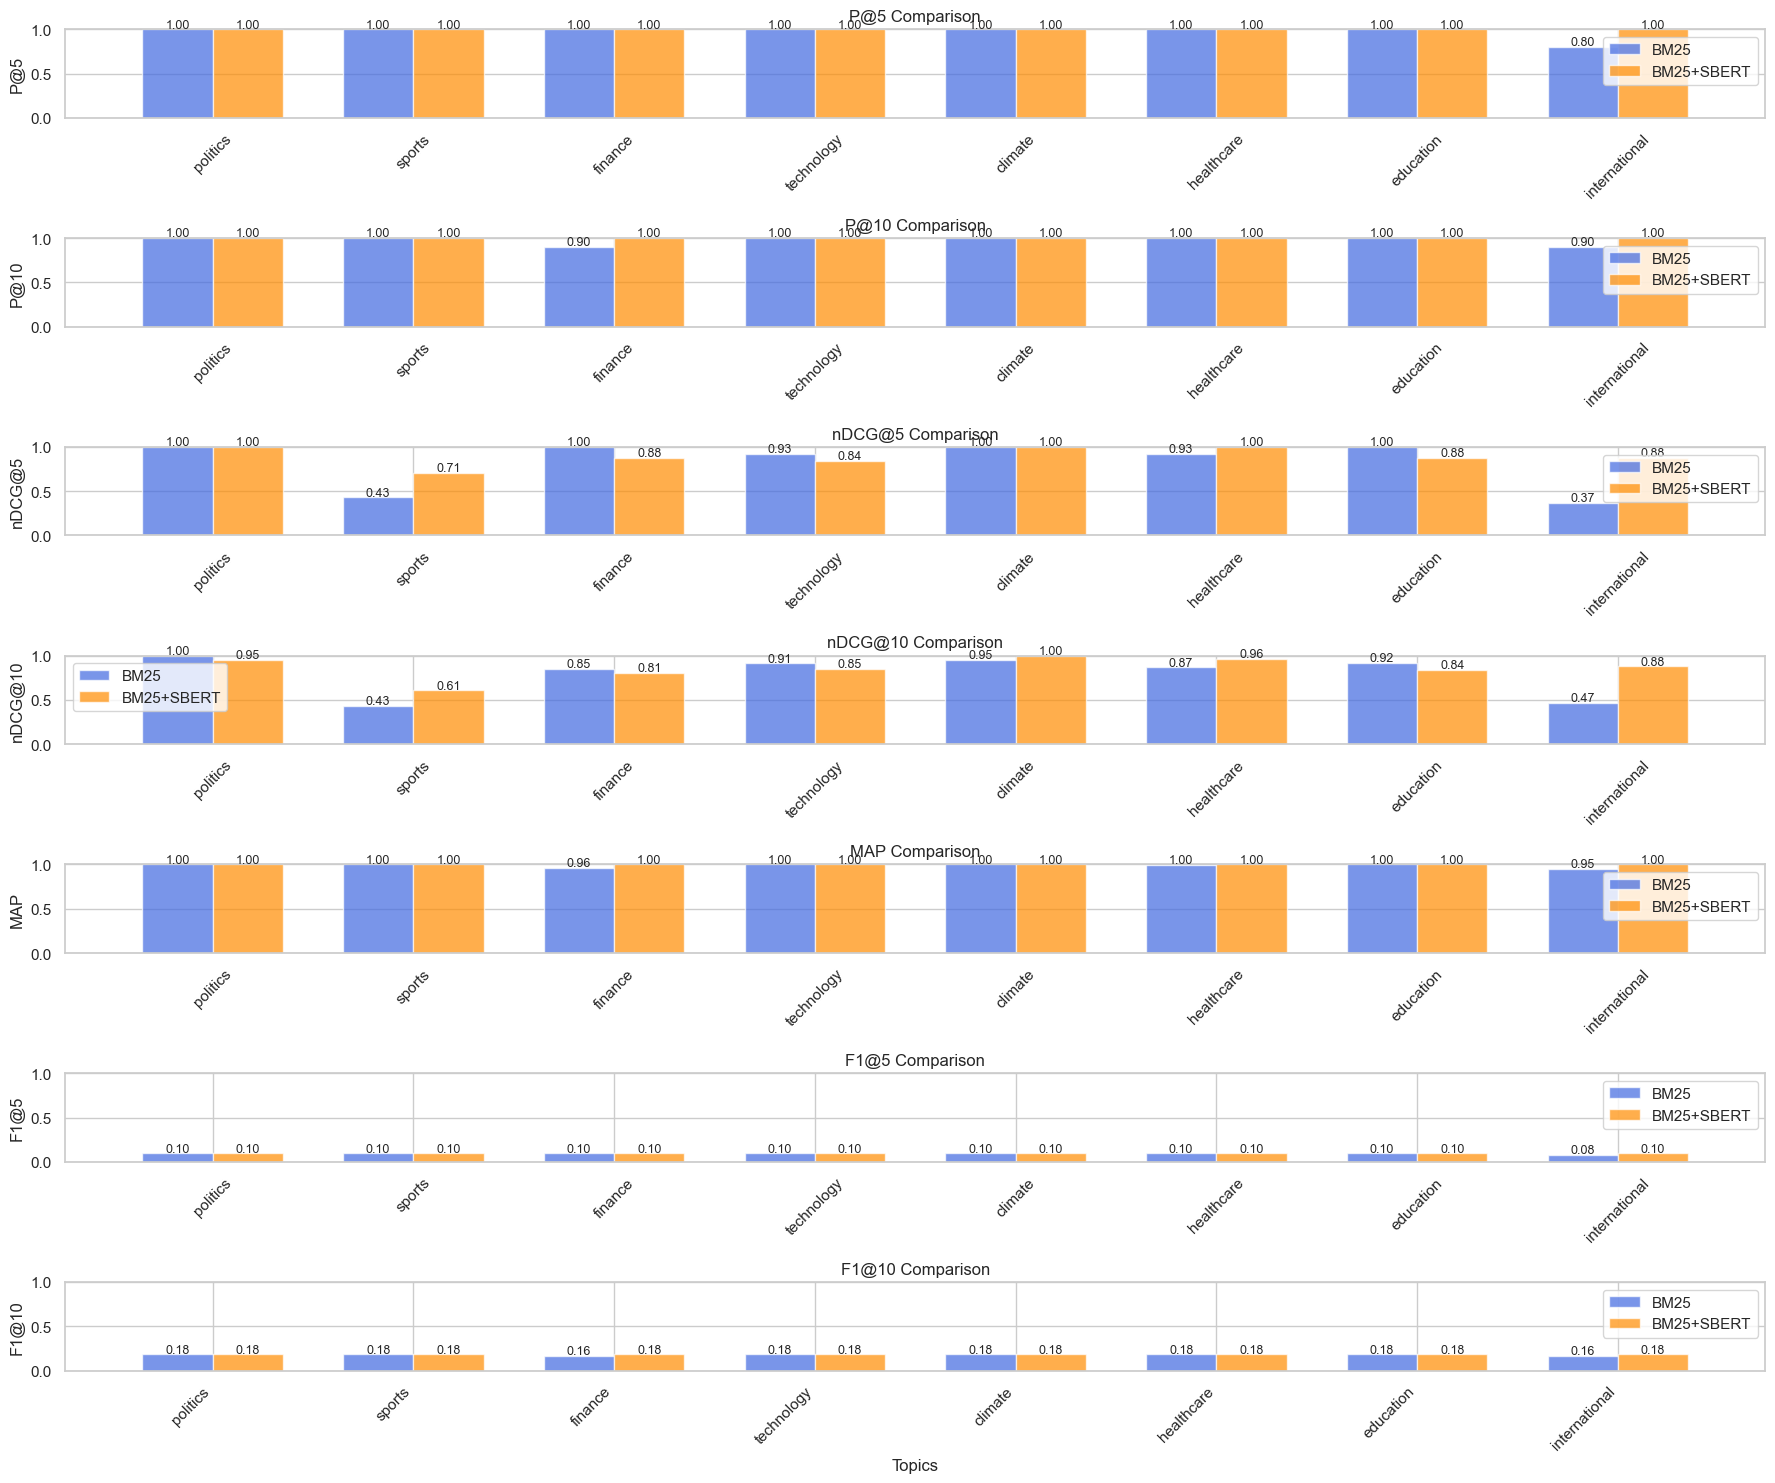


Model comparison metrics visualization displayed


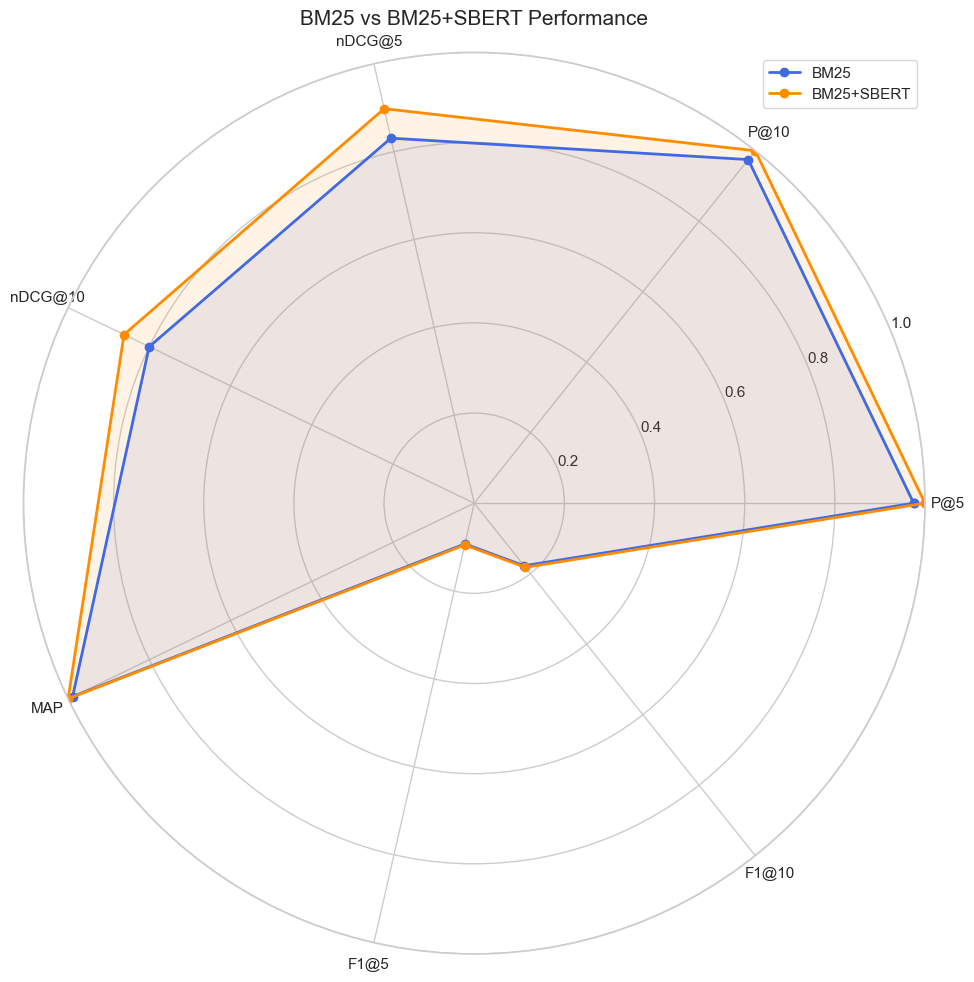

Radar chart comparison displayed


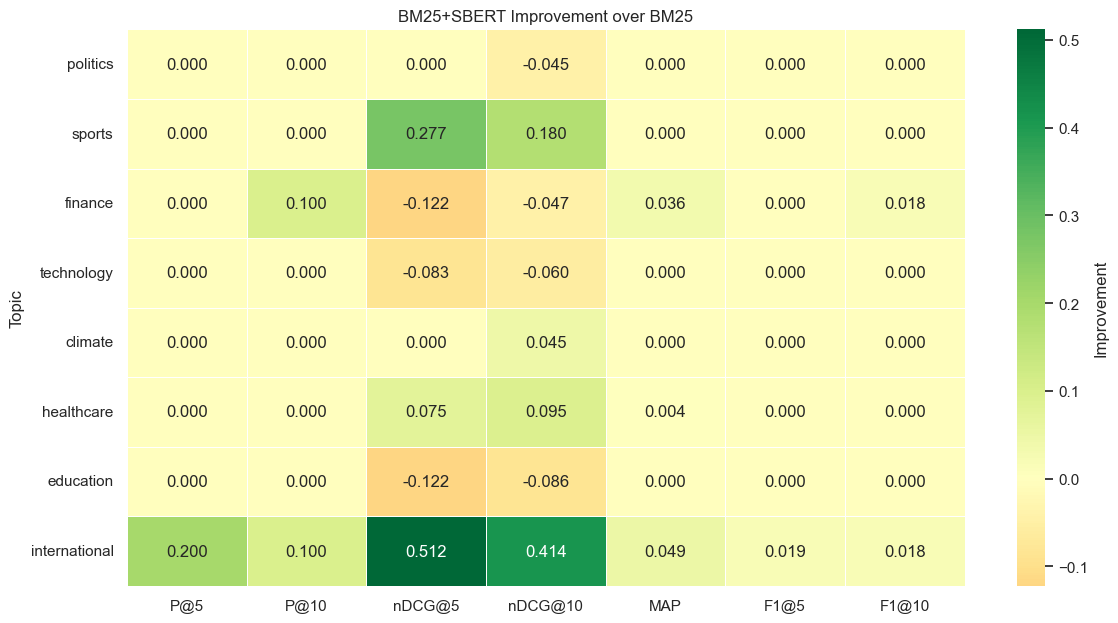

Improvement heatmap displayed
Metrics data exported to CSV files


In [13]:
def main():
    """Main function to run the evaluation."""
    # Print system info at the beginning
    print("\n--- System Information ---")
    if hasattr(torch, 'mps'):
        print(f"MPS (Apple Silicon GPU) available: {torch.backends.mps.is_available()}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Using device: {device}")
    
    csv_path = "all_the_news_cleaned.csv"
    docs = load_docs_from_csv(csv_path)
    print(f"Loaded {len(docs)} documents from {csv_path}")

    # Define query set for evaluation
    queries = {
        "politics": "implications of voter suppression on democratic representation",
        "sports": "mental health challenges facing professional athletes",
        "finance": "long-term economic impacts of quantitative easing policies",
        "technology": "ethical concerns surrounding facial recognition surveillance",
        "climate": "relationship between extreme weather events and climate change",
        "healthcare": "disparities in medical treatment across socioeconomic groups",
        "education": "effectiveness of remote learning versus traditional classroom instruction",
        "international": "diplomatic consequences of trade sanctions on global relations"
    }
    
    topics = list(queries.keys())

    # Run evaluation for both BM25 and BM25+SBERT
    bm25_results, sbert_results, bm25_metrics_df, sbert_metrics_df = run_evaluation(
        docs, queries, topics, bm25_k=50, sbert_k=10
    )
    
    # Display metrics tables in the notebook
    display_metrics_tables(bm25_metrics_df, sbert_metrics_df)
    
    # Plot comparison metrics
    plot_comparison_metrics(bm25_metrics_df, sbert_metrics_df)
    
    return bm25_results, sbert_results, bm25_metrics_df, sbert_metrics_df

if __name__ == "__main__":
    main()